# Imports

In [4]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

# Device

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# Load dataset

In [6]:
df = pd.read_csv("IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


# Check dataset

In [7]:
print(df.shape)
print(df.columns)
print(df["sentiment"].value_counts())

(50000, 2)
Index(['review', 'sentiment'], dtype='object')
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


# Convert labels to numbers

In [8]:
df["label"] = df["sentiment"].map({
    "positive": 1,
    "negative": 0
})

df.head()

,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1
3,Basically there's a family where a little boy ...,negative,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1


# Clean text

In [9]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_review"] = df["review"].apply(clean_text)
df[["review", "clean_review", "label"]].head()

,review,clean_review,label
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...,1
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,basically there s a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei s love in the time of money is a...,1


# Tokenization


In [10]:
def tokenize(text):
    return text.split()
    
df["tokens"] = df["clean_review"].apply(tokenize)
df[["clean_review", "tokens"]].head()

,clean_review,tokens
0,one of the other reviewers has mentioned that ...,"[one, of, the, other, reviewers, has, mentione..."
1,a wonderful little production the filming tech...,"[a, wonderful, little, production, the, filmin..."
2,i thought this was a wonderful way to spend ti...,"[i, thought, this, was, a, wonderful, way, to,..."
3,basically there s a family where a little boy ...,"[basically, there, s, a, family, where, a, lit..."
4,petter mattei s love in the time of money is a...,"[petter, mattei, s, love, in, the, time, of, m..."


# Build vocabulary

In [11]:
all_tokens = []

for tokens in df["tokens"]:
    all_tokens.extend(tokens)

word_counts = Counter(all_tokens)
print("Total unique words:", len(word_counts))
print(word_counts.most_common(20))

Total unique words: 99420
[('the', 668009), ('and', 324439), ('a', 323060), ('of', 289415), ('to', 268123), ('is', 211092), ('it', 190862), ('in', 186787), ('i', 175627), ('this', 151001), ('that', 143881), ('s', 129791), ('was', 95606), ('as', 91764), ('movie', 87972), ('for', 87471), ('with', 87368), ('but', 83553), ('film', 79708), ('you', 69131)]


# Create word-to-index mapping

In [12]:
MAX_VOCAB_SIZE = 20000

most_common_words = word_counts.most_common(MAX_VOCAB_SIZE - 2)

word2idx = {"<PAD>": 0, "<UNK>": 1}

for idx, (word, count) in enumerate(most_common_words, start=2):
    word2idx[word] = idx

idx2word = {idx: word for word, idx in word2idx.items()}

print("Vocabulary size:", len(word2idx))

Vocabulary size: 20000


# Convert tokens to sequences

In [13]:
def encode_tokens(tokens, word2idx):
    return [word2idx.get(token, word2idx["<UNK>"]) for token in tokens]
    
df["sequence"] = df["tokens"].apply(lambda x: encode_tokens(x, word2idx))
df[["tokens", "sequence"]].head()

,tokens,sequence
0,"[one, of, the, other, reviewers, has, mentione...","[29, 5, 2, 78, 2038, 47, 1052, 12, 101, 150, 4..."
1,"[a, wonderful, little, production, the, filmin...","[4, 391, 121, 351, 2, 1368, 2950, 7, 54, 17449..."
2,"[i, thought, this, was, a, wonderful, way, to,...","[10, 192, 11, 14, 4, 391, 96, 6, 1139, 58, 23,..."
3,"[basically, there, s, a, family, where, a, lit...","[677, 40, 13, 4, 227, 116, 4, 121, 398, 3318, ..."
4,"[petter, mattei, s, love, in, the, time, of, m...","[1, 10475, 13, 111, 9, 2, 58, 5, 290, 7, 4, 21..."


# Check sequence lengths


In [14]:
sequence_lengths = df["sequence"].apply(len)

print("Max length:", sequence_lengths.max())
print("Min length:", sequence_lengths.min())
print("Average length:", sequence_lengths.mean())

Max length: 2494
Min length: 6
Average length: 234.18392


# Choose max sequence length

In [15]:
MAX_LEN = 200

# Padding / truncation


In [16]:
def pad_sequence(sequence, max_len):
    if len(sequence) < max_len:
        sequence = sequence + [0] * (max_len - len(sequence))
    else:
        sequence = sequence[:max_len]
    return sequence

df["padded_sequence"] = df["sequence"].apply(lambda x: pad_sequence(x, MAX_LEN))
df[["sequence", "padded_sequence"]].head()

,sequence,padded_sequence
0,"[29, 5, 2, 78, 2038, 47, 1052, 12, 101, 150, 4...","[29, 5, 2, 78, 2038, 47, 1052, 12, 101, 150, 4..."
1,"[4, 391, 121, 351, 2, 1368, 2950, 7, 54, 17449...","[4, 391, 121, 351, 2, 1368, 2950, 7, 54, 17449..."
2,"[10, 192, 11, 14, 4, 391, 96, 6, 1139, 58, 23,...","[10, 192, 11, 14, 4, 391, 96, 6, 1139, 58, 23,..."
3,"[677, 40, 13, 4, 227, 116, 4, 121, 398, 3318, ...","[677, 40, 13, 4, 227, 116, 4, 121, 398, 3318, ..."
4,"[1, 10475, 13, 111, 9, 2, 58, 5, 290, 7, 4, 21...","[1, 10475, 13, 111, 9, 2, 58, 5, 290, 7, 4, 21..."


# Custom PyTorch Dataset

In [17]:
class IMDBDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels
        
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        x = torch.tensor(self.sequences[idx], dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return x, y

# Prepare data


In [18]:
X = df["padded_sequence"].tolist()
y = df["label"].tolist()

dataset = IMDBDataset(X, y)
print("Dataset size:", len(dataset))

Dataset size: 50000


# Train / validation / test split


In [19]:
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 40000
Validation size: 5000
Test size: 5000


# DataLoaders

In [20]:
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Define LSTM model

In [21]:
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, num_layers, dropout):
        super(SentimentLSTM, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        embedded = self.embedding(x)
        
        lstm_out, (hidden, cell) = self.lstm(embedded)
        
        out = self.dropout(hidden[-1])
        out = self.fc(out)
        
        return out.squeeze(1)

# Initialize model

In [22]:
VOCAB_SIZE = len(word2idx)
EMBEDDING_DIM = 128
HIDDEN_DIM = 128
OUTPUT_DIM = 1
NUM_LAYERS = 2
DROPOUT = 0.3

model = SentimentLSTM(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

print(model)

SentimentLSTM(
  (embedding): Embedding(20000, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=128, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


# Loss and optimizer

In [23]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Accuracy function

In [24]:
def binary_accuracy(preds, y):
    probs = torch.sigmoid(preds)
    rounded = torch.round(probs)
    correct = (rounded == y).float()
    acc = correct.sum() / len(correct)
    return acc

# Train one epoch


In [25]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    
    epoch_loss = 0
    epoch_acc = 0
    
    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        acc = binary_accuracy(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        epoch_acc += acc.item()
    
    return epoch_loss / len(loader), epoch_acc / len(loader)

# Evaluate one epoch

In [26]:
def evaluate(model, loader, criterion, device):
    model.eval()
    
    epoch_loss = 0
    epoch_acc = 0
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            acc = binary_accuracy(outputs, labels)
            
            epoch_loss += loss.item()
            epoch_acc += acc.item()
    
    return epoch_loss / len(loader), epoch_acc / len(loader)

# Full training loop

In [27]:
import time
import copy

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")
    
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "epoch_time": []
    }
    
    for epoch in range(num_epochs):
        start_time = time.time()
        
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        
        epoch_time = time.time() - start_time
        
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["epoch_time"].append(epoch_time)
        
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"Train Loss : {train_loss:.4f} | Train Acc : {train_acc:.4f}")
        print(f"Val Loss   : {val_loss:.4f} | Val Acc   : {val_acc:.4f}")
        print(f"Epoch Time : {epoch_time:.2f} sec")
        print("-" * 50)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), "best_sentiment_lstm.pth")
            print("Best model saved.\n")
    
    model.load_state_dict(best_model_wts)
    return model, history

# Train the model

In [28]:
NUM_EPOCHS = 5

model, history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    NUM_EPOCHS
)

Epoch 1/5
Train Loss : 0.6917 | Train Acc : 0.5214
Val Loss   : 0.6935 | Val Acc   : 0.5059
Epoch Time : 14.08 sec
--------------------------------------------------
Best model saved.

Epoch 2/5
Train Loss : 0.6906 | Train Acc : 0.5231
Val Loss   : 0.6602 | Val Acc   : 0.6072
Epoch Time : 11.67 sec
--------------------------------------------------
Best model saved.

Epoch 3/5
Train Loss : 0.6490 | Train Acc : 0.6129
Val Loss   : 0.5724 | Val Acc   : 0.7314
Epoch Time : 12.06 sec
--------------------------------------------------
Best model saved.

Epoch 4/5
Train Loss : 0.5559 | Train Acc : 0.7254
Val Loss   : 0.5492 | Val Acc   : 0.7599
Epoch Time : 10.43 sec
--------------------------------------------------
Best model saved.

Epoch 5/5
Train Loss : 0.4649 | Train Acc : 0.7895
Val Loss   : 0.4613 | Val Acc   : 0.7994
Epoch Time : 11.42 sec
--------------------------------------------------
Best model saved.



# Plot training curves

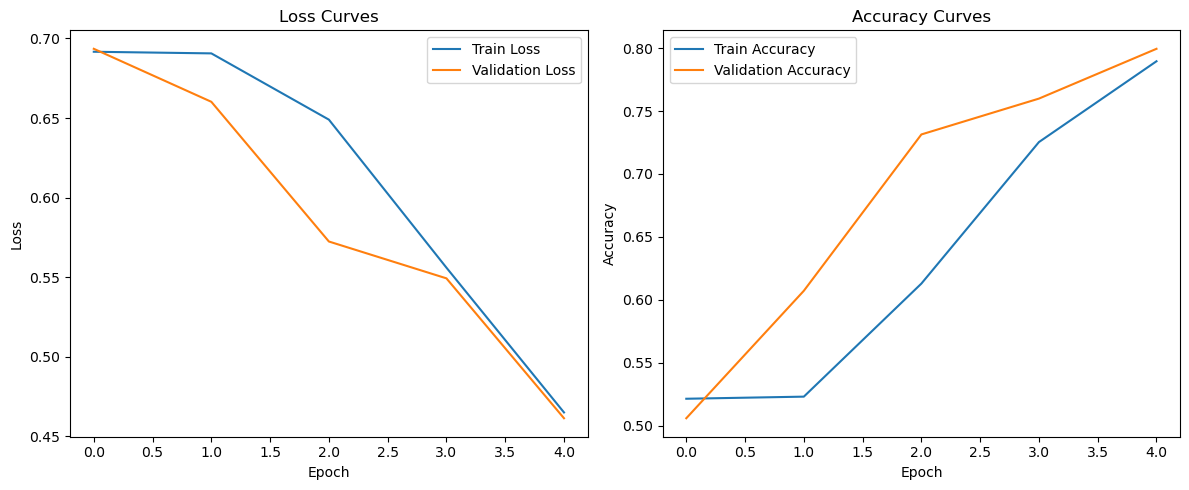

In [29]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves")
plt.legend()

plt.tight_layout()
plt.show()

# Final test evaluation

In [30]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.4688
Test Accuracy: 0.7961


# Predict on new review

In [31]:
def predict_sentiment(review, model, word2idx, max_len, device):
    model.eval()
    
    review = clean_text(review)
    tokens = tokenize(review)
    sequence = encode_tokens(tokens, word2idx)
    padded = pad_sequence(sequence, max_len)
    
    tensor = torch.tensor(padded, dtype=torch.long).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(tensor)
        prob = torch.sigmoid(output).item()
    
    sentiment = "positive" if prob >= 0.5 else "negative"
    
    return sentiment, prob

# Example prediction

In [32]:
sample_review = "This movie was absolutely amazing, the acting was fantastic and the story was wonderful."

sentiment, prob = predict_sentiment(sample_review, model, word2idx, MAX_LEN, device)

print("Review:", sample_review)
print("Predicted Sentiment:", sentiment)
print("Probability:", prob)

Review: This movie was absolutely amazing, the acting was fantastic and the story was wonderful.
Predicted Sentiment: positive
Probability: 0.6231261491775513


# Another prediction


In [33]:
sample_review = "This was one of the worst movies I have ever seen. It was boring and terrible."

sentiment, prob = predict_sentiment(sample_review, model, word2idx, MAX_LEN, device)

print("Review:", sample_review)
print("Predicted Sentiment:", sentiment)
print("Probability:", prob)

Review: This was one of the worst movies I have ever seen. It was boring and terrible.
Predicted Sentiment: negative
Probability: 0.12302352488040924


# Load saved model later

In [34]:
loaded_model = SentimentLSTM(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

loaded_model.load_state_dict(torch.load("best_sentiment_lstm.pth", map_location=device))
loaded_model.eval()

print("Model loaded successfully.")

Model loaded successfully.
